# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)


**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

---
## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [3]:
sales = pd.read_csv('kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')


Навчальна: 4322 рядків  |  Тестова: 17291 рядків


---
## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [7]:
def simple_linear_regression(input_feature, output):
    """
    Обчислює slope та intercept МНК для однієї ознаки.

    Параметри
    ----------
    input_feature : array-like, shape (n,)
    output        : array-like, shape (n,)

    Повертає
    -------
    intercept, slope : float, float
    """
    input_feature = np.array(input_feature, dtype=float)
    output        = np.array(output, dtype=float)
    n = len(input_feature)

    x_mean = input_feature.mean()
    y_mean = output.mean()

    # Compute slope
    numerator = (input_feature * output).sum() - n * x_mean * y_mean
    denominator = (input_feature**2).sum() - n * (x_mean**2)
    slope = numerator / denominator
    
    # Compute intercept
    intercept = y_mean - slope * x_mean

    return intercept, slope


### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [8]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [9]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


---
## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [10]:
def get_regression_predictions(input_feature, intercept, slope):
    """Повертає масив передбачених значень."""
    return input_feature * slope + intercept


In [11]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    
    predictions = get_regression_predictions(input_feature, intercept, slope)
    residuals = output - predictions
    rss = (residuals**2).sum()
    
    return rss


### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [12]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [13]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

In [17]:
my_house_sqft = 2650

price = get_regression_predictions(my_house_sqft, sqft_intercept, sqft_slope)
print(f'Очікувана ціна: {price:.2f}')

Очікувана ціна: 695105.98


---
## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [23]:
# Навчіть модель на ознаці bedrooms
bedrooms_intercept, bedrooms_slope = simple_linear_regression(
    train_data['bedrooms'], train_data['price']
)

# Обчисліть тестову RSS для обох моделей
rss_bedrooms = get_residual_sum_of_squares(
    test_data['bedrooms'], test_data['price'],
    bedrooms_intercept, bedrooms_slope
)

rss_sqft = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)

print(f'Bedrooms RSS: {rss_bedrooms:.2e}')
print(f'Sqft Living RSS: {rss_sqft:.2e}')




Bedrooms RSS: 2.15e+15
Sqft Living RSS: 1.20e+15


**Відповідь:** Модель, побудована на ознаці житлової площі (sqft_living), виявилася значно точнішою за модель, що базується на кількості спалень (bedrooms). Про це свідчить показник RSS (сума квадратів залишків), який для площі становить 1.20 * 10^15, що майже вдвічі менше за 2.15 * 10^15 у моделі зі спальнями. Оскільки RSS вимірює сумарне відхилення прогнозів від реальних даних, менше значення прямо вказує на те, що перша модель краще описує ринкову вартість нерухомості. Така різниця цілком логічна: житлова площа є безперервним і точнішим показником масштабу будинку, тоді як кількість спалень — це дискретна величина, яка не враховує розмір кімнат чи загальний простір. На практиці це означає, що площа дає набагато більше інформації для ціноутворення, ніж проста кількість перегородок у будівлі. Величезні значення в результатах зумовлені піднесенням різниці цін у квадрат, що є стандартним для метрики RSS у задачах регресії.

---
## ✨ Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`. Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [24]:
def inverse_regression_predictions(output, intercept, slope):
    """Повертає оцінку input_feature для заданого output."""
    estimated_feature = (output - intercept) / slope
    return estimated_feature


Орієнтовна площа для будинку ціною $800,000: 3033.48 sqft


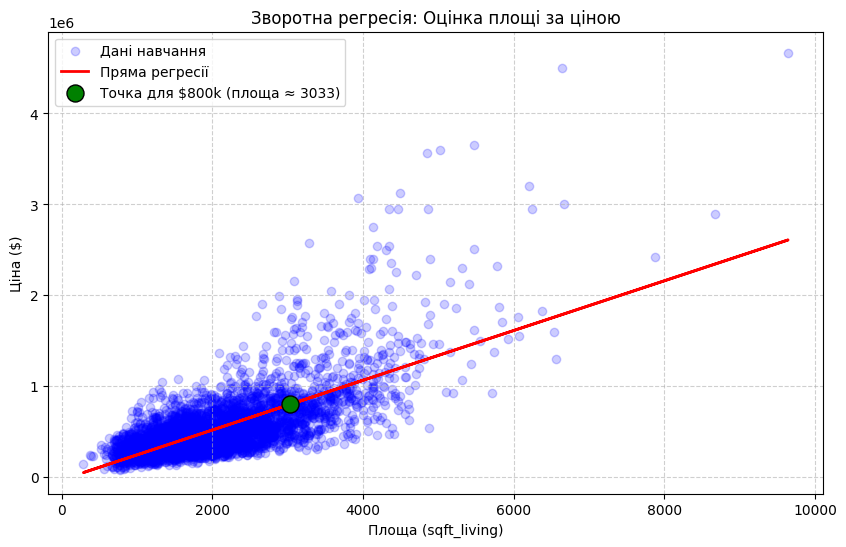

In [25]:
target_price = 800000
estimated_sqft = inverse_regression_predictions(target_price, sqft_intercept, sqft_slope)

print(f"Орієнтовна площа для будинку ціною $800,000: {estimated_sqft:.2f} sqft")

plt.figure(figsize=(10, 6))
plt.scatter(train_data['sqft_living'], train_data['price'], color='blue', alpha=0.2, label='Дані навчання')
plt.plot(train_data['sqft_living'], sqft_intercept + sqft_slope * train_data['sqft_living'], 
         color='red', linewidth=2, label='Пряма регресії')

plt.scatter(estimated_sqft, target_price, color='green', s=150, zorder=5, 
            label=f'Точка для $800k (площа ≈ {int(estimated_sqft)})', edgecolor='black')

plt.title('Зворотна регресія: Оцінка площі за ціною')
plt.xlabel('Площа (sqft_living)')
plt.ylabel('Ціна ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()